# Generating fractal noise

Every way I've done it before (fourier transforming white noise) does _not_ scale well to high dimensionality or numbers of points. Are there some faster (approximate) ways?

## Imports

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, powerlaw

from ocelot.util.random import fractal_noise_2d

## What I'm aiming for

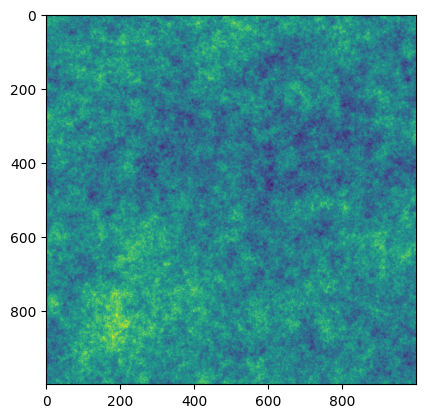

In [5]:
ground_truth = fractal_noise_2d(1000, 42)

plt.imshow(ground_truth)

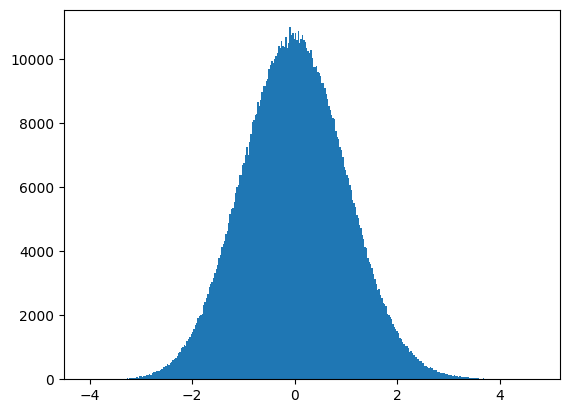

In [8]:
_ = plt.hist(ground_truth.flatten(), bins="auto")

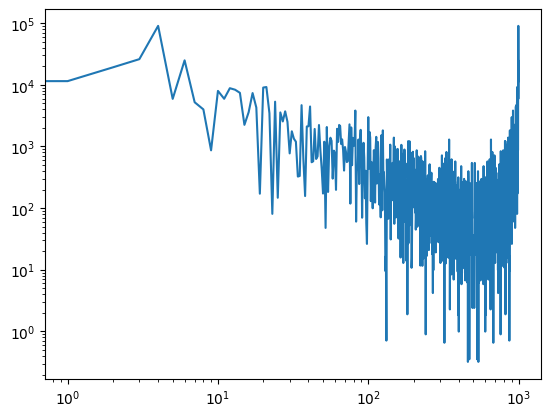

In [25]:
plt.plot(np.abs(np.fft.fft(ground_truth[:, 0]))**2)
plt.yscale("log")
plt.xscale("log")

## Approach 1: summing many random frequency components

### Investigating different frequency comp systems

In [44]:
np.stack((x, y)).shape

(2, 1000, 1000)

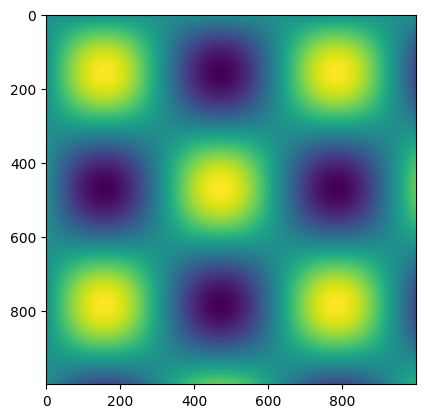

In [103]:
x_range = y_range = np.linspace(0, 10, num=1000)

x, y = np.meshgrid(x_range, y_range)

stacked_coords = np.stack((x, y))

wavelength = np.asarray((1, 1)).reshape(2, 1, 1)
values = np.prod(np.sin(stacked_coords / wavelength), axis=0)

plt.imshow(values)

In [105]:
values

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 0.00000000e+00,  1.00196954e-04,  2.00383868e-04, ...,
        -5.27633817e-03, -5.36122059e-03, -5.44556582e-03],
       [ 0.00000000e+00,  2.00383868e-04,  4.00747657e-04, ...,
        -1.05521476e-02, -1.07219040e-02, -1.08905860e-02],
       ...,
       [-0.00000000e+00, -5.27633817e-03, -1.05521476e-02, ...,
         2.77850208e-01,  2.82320088e-01,  2.86761680e-01],
       [-0.00000000e+00, -5.36122059e-03, -1.07219040e-02, ...,
         2.82320088e-01,  2.86861877e-01,  2.91374922e-01],
       [-0.00000000e+00, -5.44556582e-03, -1.08905860e-02, ...,
         2.86761680e-01,  2.91374922e-01,  2.95958969e-01]],
      shape=(1000, 1000))

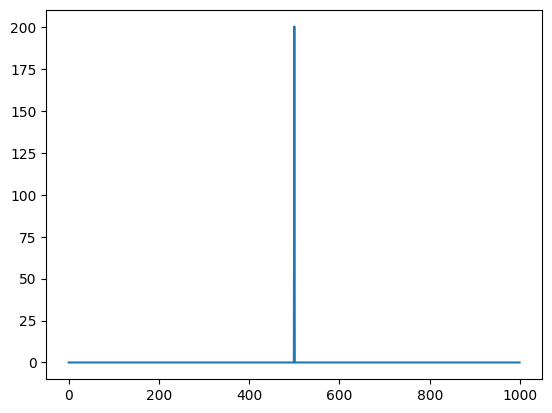

In [117]:
plt.plot(np.abs(np.fft.fftshift(np.fft.fft(values[:, 1])))**2)
# plt.yscale("log")
# plt.xscale("log")

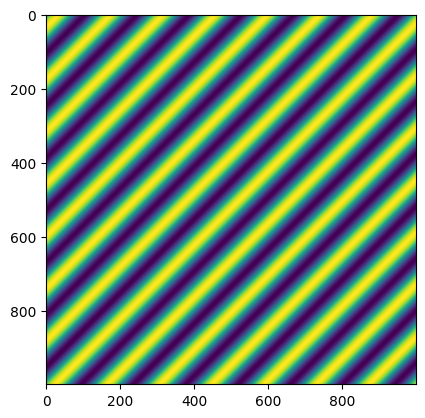

In [ ]:
x_range = y_range = np.linspace(0, 10, num=1000)

x, y = np.meshgrid(x_range, y_range)

stacked_coords = np.stack((x, y), axis=-1)

wavelength = 1 /(2*np.pi)
theta = np.radians(45)

unit_vector = np.asarray((np.cos(theta), np.sin(theta)))

values = np.sin(np.dot(stacked_coords, unit_vector) / wavelength)

plt.imshow(values)

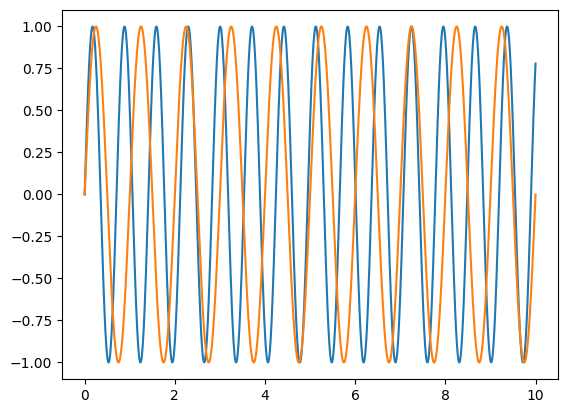

In [199]:
plt.plot(x_range, values[0, :])
plt.plot(x_range, np.sin(x_range / wavelength))

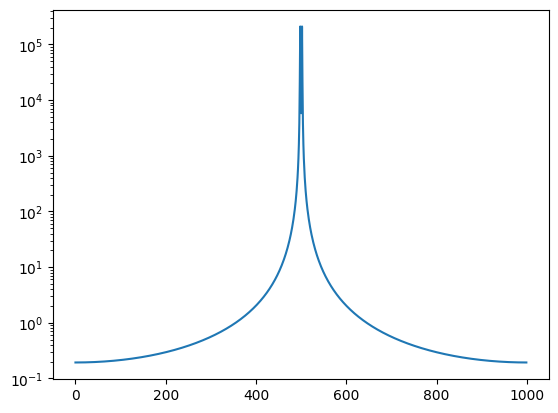

In [142]:
plt.plot(np.abs(np.fft.fftshift(np.fft.fft(values[:, 100])))**2)
plt.yscale("log")
# plt.xscale("log")

hmm, but then the fft is rotation-dependent. not sure what is best lol

### Summing them up

#### Method 1

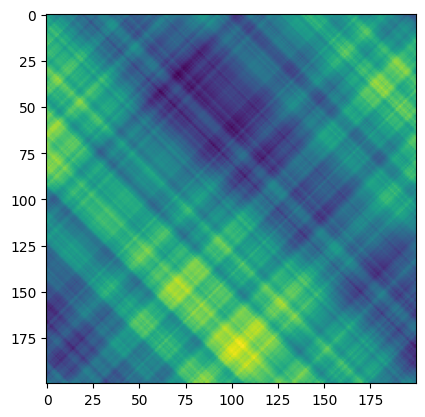

In [165]:
x_range = y_range = np.linspace(0, 999, num=200)

x, y = np.meshgrid(x_range, y_range)

stacked_coords = np.stack((x, y))


rng = np.random.default_rng(seed=42)
random_frequencies = rng.uniform(1 / 1000, 1 / 0.1, size=10000)
random_phases = rng.uniform(0, 999, size=(10000, 2))

values = np.zeros_like(x)
for freq, phase in zip(random_frequencies, random_phases):
    wavelength = 1 / freq
    values += (
        np.prod(
            np.sin((stacked_coords + np.expand_dims(phase, (1, 2))) * freq),
            axis=0,
        )
        / freq
    )

plt.imshow(values)

#### Method 2

In [169]:
coords.shape

(200, 200, 2)

In [171]:
(coords + np.expand_dims(phase, (0, 1))).shape

(200, 200, 2)

In [243]:
random_frequencies

array([0.00063662])

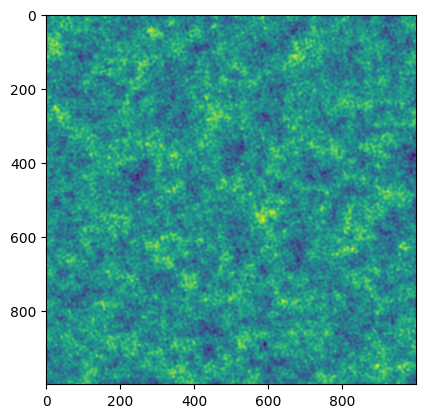

In [347]:
x_range = y_range = np.linspace(0, 10000, num=1000)

x, y = np.meshgrid(x_range, y_range)

stacked_coords = np.stack((x, y), axis=-1)

rng = np.random.default_rng(seed=42)

n_samples = 1000
max_wave = 3000
min_wave = 100

random_frequencies = rng.uniform(
    1 / max_wave * 2 * np.pi, 1 / min_wave * 2 * np.pi, size=n_samples
)
random_thetas = rng.uniform(0, 2 * np.pi, size=n_samples)
# random_phases = rng.uniform(0, 0 * np.pi, size=n_samples)


values = np.zeros_like(x)
for freq, theta in zip(random_frequencies, random_thetas):
    unit_vector = np.asarray((np.cos(theta), np.sin(theta)))
    values += np.sin((np.dot(stacked_coords, unit_vector)) * freq) / freq**0.5

values /= np.std(values)

plt.imshow(values)

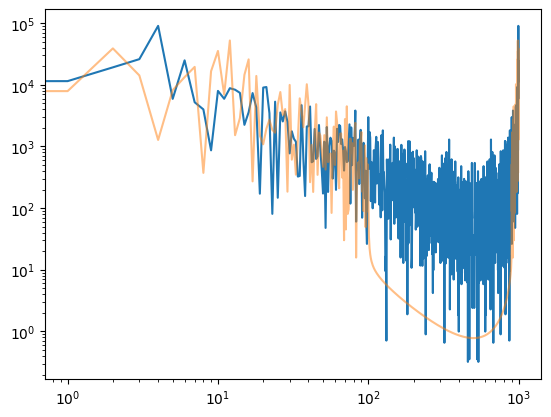

In [348]:
plt.plot(np.abs(np.fft.fft(ground_truth[:, 0]))**2)
plt.plot(np.abs(np.fft.fft(values[:, 0]))**2, alpha=0.5)
plt.yscale("log")
plt.xscale("log")

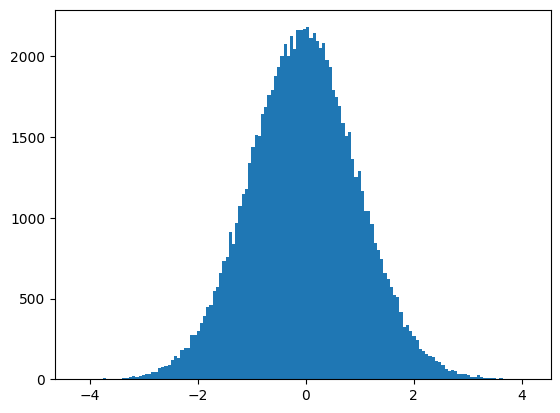

In [328]:
_ = plt.hist(values.flatten(), bins="auto")

oh! shockingly, that actually works lol. sadly, it's slow as fuck